# Capstone - macro-anchored, rates-driven tactical allocation (V1 -> V5, audited)

**Read this first.** One-page overview of a multi-stage research project. Core thesis:
**interest rates mean-revert not toward a blind historical average but toward a
macro-consistent anchor** (r* + expected inflation). The project takes that idea through
allocation, risk and cross-currency, and finally to its mathematically natural form: the
anchor as the **central tendency of a stochastic short-rate process** - with the term
premium as an *output*, the reversion estimated where it exists (the front end), and a
**full specification/data audit** that decomposes every discrepancy between test variants.

Stages, each its own notebook:

| Stage | Notebook | What it adds | Data |
|---|---|---|---|
| **V1** | `macro-anchored-allocation/` | Macro-anchored equity/bond/cash MVP | real (FRED) |
| **V2** | `V2_rates_native_curve_allocation` | Curve-native: PCA, factor mean-reversion, carry/roll/convexity | real (FRED) |
| **V3** | `TAA_..._full` (scenario engine) | VAR/OU + bootstrap, VaR/ES, stress, Kupiec | real (FRED) |
| **V4** | `TAA_..._full` (cross-currency) | G10 carry factor (long-short, risk-managed) | real (FRED) |
| *aux* | `TAA_..._full` (turnover, forensic 2022) | No-trade band / smoothing; the 2022 autopsy | real (FRED) |
| **V5a** | `MacroAnchor_LongSample_1961` | The raw anchor gap as a risk-premium predictor (honest negative OOS) | real (FRED, 1976-) |
| **V5b** | `MacroAnchor_AffineShortRate` (V6) | Anchor as OU/CIR/**HW central tendency**: TP as output, CW, common window, vintage-CPI, **reconciliation + row-by-row audit** | real (FRED) |
| **V5c** | `MacroAnchor_Panel_G10` (V2) | G10 replication of the pre-specified pipeline + US sample-cut diagnostics | real (FRED/OECD) |

> ## Honest headline - read before any Sharpe
> The allocation core is **not** alpha over a static 60/40 (real data: ~0.89 vs ~0.89). The
> validated claims are narrower: (1)-(3) **risk-managed overlays improve risk-adjusted
> outcomes** (turnover made cost-robust; a Kupiec-calibrated tail engine; a G10 carry factor
> whose Sharpe doubles under risk management); and (4) the anchor idea - having failed as
> level-timing and as a raw risk-premium signal OOS - **survives out-of-sample only in its
> theoretically disciplined form**, with the final claims hierarchy: US basket **+0.012 OOS
> (CW 10%, pre-registered strict benchmark)** -> US 10Y exact **+0.085 (CW 5%, documented
> tenor structure)** -> **G10 replication 9/9 signs, 6/9 OOS>0** (long-sample, magnitudes
> discounted per the audit). The **entire 0.012 -> 0.215 gap across specifications is
> decomposed and attributed** (tenor +0.07, target approximation +0.05, funding series
> +0.07, sample +0.06) - nothing left unexplained. Vintage-CPI robustness HOLDS.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from numpy.linalg import eigh, cholesky, eig
np.set_printoptions(suppress=True,precision=4); pd.set_option("display.float_format",lambda v:f"{v:,.3f}")
plt.rcParams.update({"figure.figsize":(10,4.5),"axes.grid":True,"grid.alpha":0.3,"figure.dpi":110,"font.size":9})
rng=np.random.default_rng(7)
# ===== condensed synthetic V2 world + book (shared lab; used only for the visual dashboard) =====
MATS=np.array([0.25,0.5,1,2,3,5,7,10,20,30]); K=len(MATS); I10=7
T=420; BURN=120; PI_TARGET=0.02; ASSUMED_TP=0.005; G1=2.0; PPY=12; TC=0.0010
def nsl(m,l): x=m/l; return np.ones_like(m,float),(1-np.exp(-x))/x,(1-np.exp(-x))/x-np.exp(-x)
F1L,F2L,F3L=nsl(MATS,2.0); dates=pd.date_range("1990-01-31",periods=T,freq="ME")
rstar=np.clip(np.linspace(0.025,0.005,T)+0.002*np.cumsum(rng.standard_normal(T))/np.sqrt(T),-0.005,0.04)
pi=np.empty(T); pi[0]=0.035; pim=0.025+0.010*np.sin(np.linspace(0,3*np.pi,T))
sg=np.zeros(T); s0=T-48; sg[s0:s0+18]=np.linspace(0,0.03,18); sg[s0+18:s0+36]=np.linspace(0.03,0,18)
for t in range(1,T): pi[t]=pi[t-1]+0.25*((pim[t]+sg[t])-pi[t-1])+0.0035*rng.standard_normal()
pi=np.clip(pi,0,0.09); short=np.empty(T); short[0]=rstar[0]+pi[0]
for t in range(1,T): short[t]=short[t-1]+0.20*((rstar[t]+pi[t])-short[t-1])+0.004*rng.standard_normal()
short=np.clip(short,0,0.12); tp=np.linspace(0.012,-0.002,T); pg=short-(rstar+pi)
cle=pd.Series(np.where(pi>0.03,-0.5,0.4)).ewm(span=6).mean().to_numpy(); zl=rng.standard_normal(T)
esh=cle*zl+np.sqrt(np.clip(1-cle**2,0,1))*rng.standard_normal(T)
b0=np.empty(T);b1=np.empty(T);b2=np.empty(T);b0[0]=rstar[0]+pi[0]+tp[0];b1[0]=G1*pg[0];b2[0]=0
for t in range(1,T):
    b0[t]=b0[t-1]+0.10*((rstar[t]+pi[t]+tp[t])-b0[t-1])+0.003*zl[t]
    b1[t]=b1[t-1]+0.15*(G1*pg[t]-b1[t-1])+0.003*rng.standard_normal(); b2[t]=b2[t-1]+0.20*(0-b2[t-1])+0.0035*rng.standard_normal()
Y=np.clip(b0[:,None]*F1L+b1[:,None]*F2L+b2[:,None]*F3L+0.0006*rng.standard_normal((T,K)),0.0005,0.16)
D=MATS.astype(float);Cc=MATS**2;dY=np.vstack([np.zeros((1,K)),np.diff(Y,axis=0)]);h=1/12
roll=np.zeros((T,K))
for t in range(T): roll[t]=D*(Y[t]-np.interp(MATS-h,MATS,Y[t]))
RET=Y/12+roll-D[None,:]*dY+0.5*Cc[None,:]*dY**2+0.0008*rng.standard_normal((T,K))
ep=np.empty(T);ep[0]=0.055;epm=0.055+0.015*np.sin(np.linspace(0.5,2.5*np.pi,T))
for t in range(1,T): ep[t]=ep[t-1]+0.06*(epm[t]-ep[t-1])+0.003*rng.standard_normal()
ep=np.clip(ep,0.02,0.11); eq=short/12+(0.6*(ep-(Y[:,I10]-pi))+0.02)/12+(0.16/np.sqrt(12))*(1+0.3*np.abs(np.roll(esh,1)))*esh; rf=short/12
Sig=np.cov(np.diff(Y[:BURN],axis=0),rowvar=False);va,ve=eigh(Sig);o=np.argsort(va)[::-1];Bload=ve[:,o][:,:3].copy()
if Bload[:,0].mean()<0:Bload[:,0]*=-1
if Bload[-1,1]-Bload[0,1]<0:Bload[:,1]*=-1
if Bload[K//2,2]<0:Bload[:,2]*=-1
muY=Y[:BURN].mean(0);F=(Y-muY)@Bload
def zx(x): s=pd.Series(np.asarray(x,float),index=dates);return ((s-s.expanding(36).mean())/s.expanding(36).std()).clip(-3,3)
gl=F[:,0]-(pd.Series(short-pi,index=dates).expanding(36).mean().to_numpy()+pi+ASSUMED_TP-muY@Bload[:,0])
vd=np.tanh(zx(gl).to_numpy());vs=np.tanh(-zx(F[:,1]).to_numpy());vf=np.tanh(-zx(F[:,2]-F[:BURN,2].mean()).to_numpy())
fr=[i for i,m in enumerate(MATS) if m<=2];be=[i for i,m in enumerate(MATS) if 2<m<=7];lo=[i for i,m in enumerate(MATS) if m>7]
bret=np.column_stack([RET[:,fr].mean(1),RET[:,be].mean(1),RET[:,lo].mean(1)])
WB=np.tile([0.3,0.3,0.4],(T,1)).astype(float);WB[:,2]+=0.18*vd;WB[:,0]-=0.18*vd;WB[:,0]+=0.14*vs;WB[:,2]-=0.14*vs
WB[:,1]+=0.10*vf;WB[:,0]-=0.05*vf;WB[:,2]-=0.05*vf;WB=np.clip(WB,0,None);WB/=WB.sum(1,keepdims=True)
sleeve=pd.Series((np.roll(WB,1,0)*bret).sum(1),index=dates);sleeve.iloc[0]=0
z_erp=zx(ep-(Y[:,I10]-pi)).to_numpy();wer=np.clip(0.5+0.2*np.tanh(z_erp),0,None);wbr=np.clip(0.4+0.2*np.tanh(zx(gl).to_numpy()),0,None)
veq=pd.Series(eq,index=dates).rolling(12).std().to_numpy()*np.sqrt(12);vbd=sleeve.rolling(12).std().to_numpy()*np.sqrt(12)
ceb=pd.Series(eq,index=dates).rolling(36).corr(sleeve).to_numpy();ip=np.clip(pi-PI_TARGET,0,None)
zrv=zx(pd.Series(dY[:,I10],index=dates).rolling(12).std().to_numpy()*np.sqrt(12)).to_numpy()
vp=np.sqrt(np.clip(wer**2*veq**2+wbr**2*vbd**2+2*wer*wbr*ceb*veq*vbd,1e-8,None));mlt=np.clip(0.10/vp,None,1.5)
thr=1/(1+8*ip+0.1*np.clip(zrv,0,None));w_eq=np.clip(mlt*thr*wer,0,0.9);w_bd=np.clip(mlt*thr*wbr,0,0.9)
to=w_eq+w_bd;scl=np.where(to>1,1/to,1);w_eq*=scl;w_bd*=scl;w_cash=1-w_eq-w_bd
strat=pd.Series(np.roll(w_eq,1)*eq+np.roll(w_bd,1)*sleeve.to_numpy()+np.roll(w_cash,1)*rf,index=dates);strat.iloc[0]=0
eq_excess=eq-rf
print("Dashboard inputs ready (synthetic).")

Dashboard inputs ready (synthetic).


## The real-data results ledger (what actually ran on FRED)

The numbers below are the **documented real-data findings** from the V1/V2 runs on FRED
(2004–2026, 270 months) — recorded here so the overview carries the honest result, not a
synthetic stand-in.

In [2]:
ledger=pd.DataFrame({
 "Strategy V2 curve (net)":{"AnnRet":0.089,"AnnVol":0.079,"Sharpe":0.888,"MaxDD":-0.177,"Turnover":0.985},
 "Strategy V1 10Y (net)":  {"AnnRet":0.079,"AnnVol":0.081,"Sharpe":0.760,"MaxDD":-0.202,"Turnover":0.989},
 "Static 60/40":           {"AnnRet":0.097,"AnnVol":0.089,"Sharpe":0.886,"MaxDD":-0.187,"Turnover":0.191},
 "Equity":                 {"AnnRet":0.150,"AnnVol":0.143,"Sharpe":0.922,"MaxDD":-0.239,"Turnover":0.000},
}).T
print("PILLAR 0 - REAL-DATA CROSS-ASSET (FRED 2004-2026):\n"); print(ledger.to_string())
print("  edge concentrates in EASY regimes; level & slope ~random walk (kappa 0.022/~0)")

print("\nPILLAR 1 - TURNOVER MADE COST-ROBUST (real V2 weights):")
print("  smoothing lam=0.06: turnover 0.985 -> 0.276 | net Sharpe 0.904 | @50bp 0.891 beats un-smoothed 0.839")

print("\nPILLAR 2 - V3 SCENARIO ENGINE CALIBRATED ON REAL DATA:")
print("  Kupiec strategy VaR: 95% -> 4.94% exc (LR 0.00) | 99% -> 1.23% (LR 0.08) => WELL CALIBRATED")
print("  bootstrap ES99 17.1% vs Gaussian 11.4% (fat tail exposed) | shock corr Level<->Eq +0.12")

print("\nPILLAR 3 - V4 G10 CARRY FACTOR (long-short, dollar-neutral, real):")
print("  naive Sharpe 0.27 / MaxDD -17% -> risk-managed 0.66 / -4.7% | added to V2 book: 0.887 -> 0.919")

print("\nPILLAR 4 - THE ANCHOR AS A SHORT-RATE PROCESS: THE RESULT AND ITS AUDIT (1976-2026)")
print("  honesty: corr(TP_HW10, slope) 0.35 | corr(TP_HW10, Kim-Wright) 0.70  (OU/CIR w/o anchor fail both)")
print("  in-sample: NW t monotone in tenor 2.06 (2y) -> 3.87 (10y); basket t 3.04")
print("  CLAIMS HIERARCHY (out-of-sample, expanding-mean benchmark):")
print("    strict US benchmark (pre-registered): basket OOS +0.012 | CW t 1.31 (10% star)")
print("    tenor structure (documented ex-ante): 10Y exact OOS +0.085 | CW t 2.25 (5% star)")
print("    common window: slope/FB lose their 5% stars (CW 1.60/1.62, OOS<0); legacy gap -0.47, no star")
print("    G10 replication (same pre-specified pipeline): 9/9 positive betas | OOS>0 in 6/9 | CW>10% in 7/9")
print("      failures declared: AUS OOS -0.11, NOR -0.08, CHE n=47; JPN dropped (ZLB - absence flagged)")
print("  SPECIFICATION/DATA AUDIT - the 0.012 -> 0.215 gap fully attributed:")
print("    tenor concentration +0.07 (basket -> 10Y exact) | target duration-approx +0.05 (0.085 -> 0.140)")
print("    funding series +0.07 (TB3MS -> interbank, same rows: 0.135 -> 0.208) | sample 1976 -> 1964: +0.06")
print("    signal IDENTICAL across specs (B1==B2 exactly): the gap is target/source/sample, never the signal")
print("    1997-only re-estimation: kappa -> 0.0001, OOS collapses => kappa is identified by PRE-ZLB history")
print("    pre-registered rule applied: panel = long-sample replication; affine common-window = strict benchmark")
print("  robustness: publication-lag CPI HOLDS (+0.0093, CW 1.32) | funding-series sensitivity DECLARED (both reported)")
print("  economic value: model-E[rx] sizing Sharpe 0.58 -> 0.71-0.75 | z-sized MaxDD -19.7% -> -6.1%")
print("  caveats: marginal stars, multiple-testing discount (3 formulations), duration-approx target flatters")

PILLAR 0 - REAL-DATA CROSS-ASSET (FRED 2004-2026):

                         AnnRet  AnnVol  Sharpe  MaxDD  Turnover
Strategy V2 curve (net)   0.089   0.079   0.888 -0.177     0.985
Strategy V1 10Y (net)     0.079   0.081   0.760 -0.202     0.989
Static 60/40              0.097   0.089   0.886 -0.187     0.191
Equity                    0.150   0.143   0.922 -0.239     0.000
  edge concentrates in EASY regimes; level & slope ~random walk (kappa 0.022/~0)

PILLAR 1 - TURNOVER MADE COST-ROBUST (real V2 weights):
  smoothing lam=0.06: turnover 0.985 -> 0.276 | net Sharpe 0.904 | @50bp 0.891 beats un-smoothed 0.839

PILLAR 2 - V3 SCENARIO ENGINE CALIBRATED ON REAL DATA:
  Kupiec strategy VaR: 95% -> 4.94% exc (LR 0.00) | 99% -> 1.23% (LR 0.08) => WELL CALIBRATED
  bootstrap ES99 17.1% vs Gaussian 11.4% (fat tail exposed) | shock corr Level<->Eq +0.12

PILLAR 3 - V4 G10 CARRY FACTOR (long-short, dollar-neutral, real):
  naive Sharpe 0.27 / MaxDD -17% -> risk-managed 0.66 / -4.7% | added to V

## Visual table of contents (synthetic dashboard)

One figure, four panels — the signature output of each stage, regenerated on the shared
synthetic lab so the whole arc is visible at a glance. **Synthetic — illustrative of the
machinery only.**

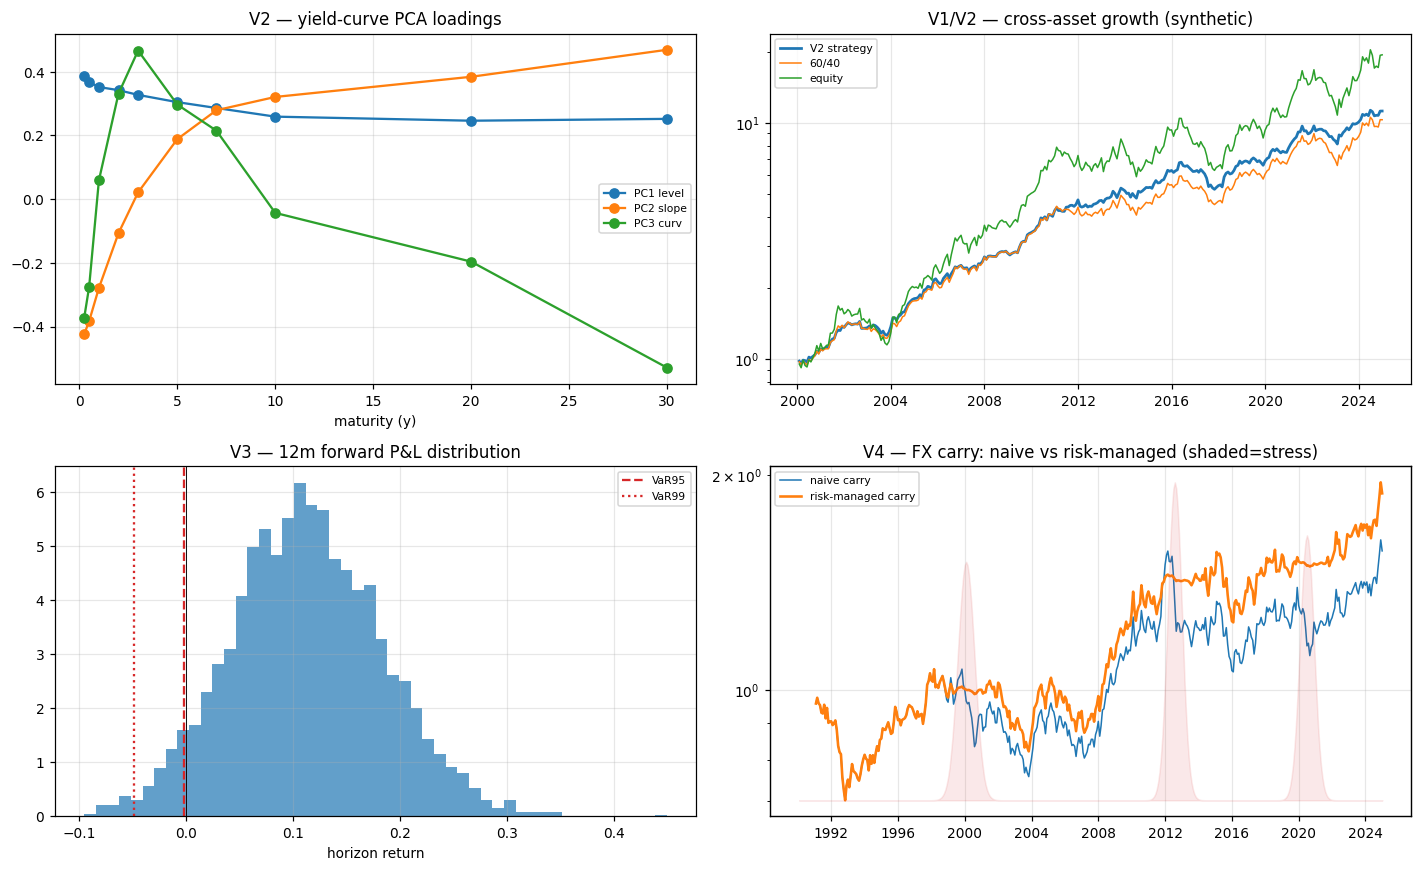

12m VaR95 0.1% | VaR99 4.9% (synthetic current book)


In [3]:
# V3 quick scenario engine: VAR(1) on [factors, eq-excess] -> 12m MC P&L on current book
S=np.column_stack([F[:,0],F[:,1],F[:,2],eq_excess]);X=np.column_stack([np.ones(len(S)-1),S[:-1]])
co=np.linalg.lstsq(X,S[1:],rcond=None)[0];Aco=co[1:].T;cco=co[0];E=S[1:]-X@co;Cov=np.cov(E,rowvar=False)
L=cholesky(Cov+1e-12*np.eye(4));WBc=WB[-1];we_c,wb_c,wc_c=w_eq[-1],w_bd[-1],w_cash[-1];rf_c=rf[-1]
N,H=4000,12;s=np.tile(S[-1],(N,1));pnl=np.zeros(N)
fac=np.zeros((N,H,4))
for t in range(H): s=cco+s@Aco.T+rng.standard_normal((N,4))@L.T;fac[:,t]=s
for i in range(N):
    Yp=muY[None,:]+fac[i,:,:3]@Bload.T;Yprev=np.vstack([Y[-1],Yp[:-1]]);dy=Yp-Yprev;port=np.zeros(H)
    for t in range(H):
        yr=np.interp(MATS-h,MATS,Yprev[t]);rs=Yprev[t]/12+D*(Yprev[t]-yr)-D*dy[t]+0.5*Cc*dy[t]**2
        bk=np.array([rs[fr].mean(),rs[be].mean(),rs[lo].mean()]);port[t]=we_c*(rf_c+fac[i,t,3])+wb_c*(bk@WBc)+wc_c*rf_c
    pnl[i]=np.prod(1+port)-1
# V4 quick carry illustration: HY carry premium + stress crashes, naive vs throttled
stress=np.zeros(T)
for c0,w,a in [(T-300,6,1.8),(T-150,5,2.4),(T-55,5,2.0)]: stress+=a*np.exp(-0.5*((np.arange(T)-c0)/w)**2)
carry_r=0.05/12+ (0.10/np.sqrt(12))*rng.standard_normal(T) - 0.020*np.maximum(stress-0.7,0)
naive_c=pd.Series(carry_r,index=dates); st=pd.Series(stress,index=dates).rolling(6).mean().fillna(0)
rm_c=naive_c*(1/(1+6*st))

fig,ax=plt.subplots(2,2,figsize=(13,8))
for i,lab in enumerate(["PC1 level","PC2 slope","PC3 curv"]): ax[0,0].plot(MATS,Bload[:,i],marker="o",label=lab)
ax[0,0].set_title("V2 — yield-curve PCA loadings");ax[0,0].set_xlabel("maturity (y)");ax[0,0].legend(fontsize=7)
gst=dates[BURN]
for r,nm,lw in [(strat,"V2 strategy",1.8),(pd.Series(0.6*eq+0.4*bret[:,1],index=dates),"60/40",1.0),(pd.Series(eq,index=dates),"equity",1.0)]:
    cu=(1+r.loc[gst:].fillna(0)).cumprod();ax[0,1].plot(cu.index,cu.values,lw=lw,label=nm)
ax[0,1].set_yscale("log");ax[0,1].set_title("V1/V2 — cross-asset growth (synthetic)");ax[0,1].legend(fontsize=7)
ax[1,0].hist(pnl,bins=50,density=True,alpha=0.7,color="C0")
ax[1,0].axvline(np.percentile(pnl,5),color="C3",ls="--",label="VaR95");ax[1,0].axvline(np.percentile(pnl,1),color="C3",ls=":",label="VaR99")
ax[1,0].axvline(0,color="k",lw=0.6);ax[1,0].set_title("V3 — 12m forward P&L distribution");ax[1,0].set_xlabel("horizon return");ax[1,0].legend(fontsize=7)
for r,nm,lw in [(naive_c,"naive carry",1.0),(rm_c,"risk-managed carry",1.7)]:
    cu=(1+r.iloc[12:].fillna(0)).cumprod();ax[1,1].plot(cu.index,cu.values,lw=lw,label=nm)
a2=ax[1,1].twinx();a2.fill_between(dates,0,stress,color="C3",alpha=0.10);a2.set_yticks([])
ax[1,1].set_yscale("log");ax[1,1].set_title("V4 — FX carry: naive vs risk-managed (shaded=stress)");ax[1,1].legend(fontsize=7)
plt.tight_layout();plt.show()
print("12m VaR95 %.1f%% | VaR99 %.1f%% (synthetic current book)"%(-np.percentile(pnl,5)*100,-np.percentile(pnl,1)*100))

## Verdict, limitations, and how to read it

**What the stack demonstrates.** One economic idea taken all the way and then **audited**:
macro-anchored duration -> curve allocation -> tail risk -> global carry -> the anchor as a
short-rate central tendency with the term premium as output - and, when two of its own
results disagreed, a reconciliation ladder and a row-by-row data audit that attributed
every point of the gap. Expanding windows, lagged weights, pre-registered reading rules,
saved audit files, on real FRED/OECD data throughout.

**The honest verdict - theory as regularization.** The signal with the best in-sample fit
(the raw anchor gap, R2 0.13) has the worst out-of-sample record (-0.47); the theoretically
disciplined form (HW central tendency) is the only OOS survivor, and its edge concentrates
at the long end. The claims hierarchy is: basket +0.012 (10%, strict) -> 10Y exact +0.085
(5%) -> G10 9/9 signs / 6/9 OOS (long-sample replication, magnitudes discounted per audit).
An honest structural finding rides along: **the reversion parameter is identified by the
pre-ZLB history** - the zero-rate decade alone contains no information about it.

**Limitations.** Marginal significance levels with a multiple-testing discount owed (three
formulations); duration-approximated targets flatter OOS by ~+0.05 (quantified); results
are sensitive to the funding-rate series by ~+0.07 (T-bill vs interbank - both reported,
neither picked); OECD data are revised (ALFRED vintages = full treatment); one-factor
misfit means part of any model TP is model error; carry gross of FX costs; V4 basis leg
still needs BIS/Bloomberg.

**Next steps.** (1) Working paper: the audit *is* the distinctive section. (2) ALFRED
vintages. (3) FX costs on the carry sleeve; real basis. (4) The engine repo carries the
machinery separately from the claims.